# Does a bad monsoon still hurt growth?

Tests how much a weak monsoon lowers farm and GDP growth, and whether that effect has changed since the 1950s.

Data: MoSPI National Accounts (eSankhyiki), joined from the 2011-12 back series, the 2011-12 series and the new 2022-23 series. Rainfall from rainfall_record.ipynb.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

RAW = "data/raw/"
CLEAN = "data/clean/"

AGRI = "Agriculture, Livestock, Forestry and Fishing"
TOTAL = "Total Gross Value Added"

## Reading the MoSPI files

MoSPI revises each year several times, so I keep only the latest estimate. Non-farm GVA is total GVA minus agriculture. Mining is a separate line, so it's not in agriculture.

In [2]:
REVISION_ORDER = [
    "First Advance Estimates", "Second Advance Estimates", "Provisional Estimates",
    "First Revised Estimates", "Second Revised Estimates", "Third Revised Estimates",
    "Final Estimates", "Additional Revision",
]

def keep_latest(df, by):
    df = df.copy()
    df["rank"] = df["revision"].map({r: i for i, r in enumerate(REVISION_ORDER)}).fillna(-1)
    return df.sort_values("rank").groupby(by).tail(1)

def gva_levels(filename):
    d = pd.read_csv(RAW + filename)
    d = d[d["subindustry"].isna() & d["institutional_sector"].isna() & d["industry"].isin([AGRI, TOTAL])]
    d = keep_latest(d, ["year", "industry"])
    wide = d.pivot(index="year", columns="industry", values="constant_price").astype(float)
    wide = wide.rename(columns={AGRI: "agri", TOTAL: "total"})
    wide["nonagri"] = wide["total"] - wide["agri"]
    return wide

back = gva_levels("mospi_nas_gva_2011_12_base_back_series.csv")
cur = gva_levels("mospi_nas_gva_2011_12_base_current_series.csv")
new = gva_levels("mospi_nas_gva_2022_23_base.csv")

# the back series and the current series both have 2011-12, they should agree
pd.DataFrame({"back series": back.loc["2011-12"], "current series": cur.loc["2011-12"]})

,back series,current series
industry,,
agri,1501947.0,1501947.0
total,8106948.0,8106945.0
nonagri,6605001.0,6604998.0


## Joining the three series

Base years price things differently, so I join growth rates, not levels:
1951-52 to 2011-12 from the back series, 2012-13 to 2022-23 from the 2011-12 series, 2023-24 onwards from the 2022-23 series.

In [3]:
def pct_growth(levels):
    return levels.sort_index().pct_change() * 100

growth = pd.concat([
    pct_growth(back).loc[:"2011-12"].iloc[1:],
    pct_growth(cur).loc["2012-13":"2022-23"],
    pct_growth(new).loc["2023-24":],
])
growth = growth.rename(columns={"agri": "agri_growth", "total": "gva_growth", "nonagri": "nonagri_growth"})

levels = pd.concat([back.loc[:"2011-12"], cur.loc["2012-13":"2022-23"], new.loc["2023-24":]])
growth["agri_share"] = levels["agri"] / levels["total"] * 100

gdp_raw = pd.read_csv(RAW + "mospi_nas_gdp_all_series.csv")

def gdp_growth(base_year, series):
    d = gdp_raw[(gdp_raw["base_year"] == base_year) & (gdp_raw["series"] == series)]
    d = keep_latest(d, ["year"]).set_index("year")["constant_price"].astype(float)
    return pct_growth(d)

growth["gdp_growth"] = pd.concat([
    gdp_growth("2011-12", "Back").loc[:"2011-12"].iloc[1:],
    gdp_growth("2011-12", "Current").loc["2012-13":"2022-23"],
    gdp_growth("2022-23", "Current").loc["2023-24":],
])
growth.index.name = "fiscal_year"
print(len(growth), "years,", growth.index[0], "to", growth.index[-1])
growth.round(2).tail()

75 years, 1951-52 to 2025-26


industry,agri_growth,gva_growth,nonagri_growth,agri_share,gdp_growth
fiscal_year,,,,,
2021-22,4.62,9.38,10.30,15.64,9.69
2022-23,6.26,7.21,7.39,15.50,7.61
2023-24,2.69,7.43,8.61,19.04,7.32
2024-25,4.14,7.15,7.85,18.50,7.19
2025-26,3.27,7.91,8.96,17.71,7.82


Check: my GDP growth against the Economic Survey 2025-26 (Table 1.7). Both use the same NSO data, so the gap should be close to zero.

In [4]:
es = pd.read_excel(RAW + "es2025_26_table1_7.xlsx", header=None)
es = es[es[0].astype(str).str.match(r"^\d{4}-\d{2}")]
es_gdp = es.set_index(es[0].str[:7])[9].astype(float)
es_growth = es_gdp.pct_change() * 100

gap = (growth.loc["1951-52":"2022-23", "gdp_growth"] - es_growth.loc["1951-52":"2022-23"]).abs()
print("largest gap with the Economic Survey, 1951-52 to 2022-23:", round(gap.max(), 2), "percentage points")

largest gap with the Economic Survey, 1951-52 to 2022-23: 0.0 percentage points


## How much of the economy is farming

Agriculture's share of GVA, every tenth year. It stops at 2021-22 because the new 2022-23 base measures farming differently, so later shares aren't comparable.

In [5]:
growth["agri_share"].iloc[::10].round(1).to_frame("agriculture, % of GVA")

,"agriculture, % of GVA"
fiscal_year,
1951-52,61.2
1961-62,55.0
1971-72,48.1
1981-82,42.1
1991-92,34.0
2001-02,26.6
2011-12,18.5
2021-22,15.6


## Matching each year's monsoon

The monsoon of a year goes with that financial year (monsoon 2009 with 2009-10), since the kharif crop is harvested in the same year.

The departure from normal is split into a deficit and a surplus, because droughts usually hurt more than good years help (Gadgil and Gadgil, 2006).

In [6]:
rain = pd.read_csv(CLEAN + "monsoon_rainfall_1871_2026.csv").set_index("year")

growth["monsoon_year"] = [int(y[:4]) for y in growth.index]
df = growth.join(rain[["pct_of_normal", "departure", "category"]], on="monsoon_year")
df["deficit"] = df["departure"].clip(upper=0)
df["surplus"] = df["departure"].clip(lower=0)
df["after_1991"] = (df["monsoon_year"] >= 1991).astype(int)
df["covid_year"] = (df.index == "2020-21").astype(int)
df[["agri_growth", "gdp_growth", "pct_of_normal", "deficit", "surplus"]].round(1).tail(8)

,agri_growth,gdp_growth,pct_of_normal,deficit,surplus
fiscal_year,,,,,
2018-19,2.1,6.5,92.6,-7.4,0.0
2019-20,6.2,3.9,111.5,0.0,11.5
2020-21,4.0,-5.8,110.2,0.0,10.2
2021-22,4.6,9.7,100.7,0.0,0.7
2022-23,6.3,7.6,106.5,0.0,6.5
2023-24,2.7,7.3,94.4,-5.6,0.0
2024-25,4.1,7.2,107.6,0.0,7.6
2025-26,3.3,7.8,107.8,0.0,7.8


## A first look

Average growth by type of monsoon year, 1951-52 to 2025-26.

In [7]:
order = ["deficient", "below normal", "normal", "above normal", "excess"]
summary = df.groupby("category")[["agri_growth", "nonagri_growth", "gdp_growth"]].mean().reindex(order)
summary["years"] = df["category"].value_counts().reindex(order)
summary.round(1)

,agri_growth,nonagri_growth,gdp_growth,years
category,,,,
deficient,-2.9,6.1,3.2,13
below normal,0.9,5.3,3.8,9
normal,3.8,7.2,6.0,23
above normal,5.2,5.4,5.3,16
excess,6.3,6.0,6.0,14


## Regressions

growth = constant + a × deficit + b × surplus

If a = 0.5, a monsoon 10% below normal means growth about 5 points lower. I use Newey-West standard errors because growth in one year is linked to the year before. GDP and non-farm models include a dummy for 2020-21 (COVID).

In [8]:
def fit(formula, data=df):
    return smf.ols(formula, data=data).fit(cov_type="HAC", cov_kwds={"maxlags": 1})

models = {
    "agriculture": fit("agri_growth ~ deficit + surplus"),
    "GDP": fit("gdp_growth ~ deficit + surplus + covid_year"),
    "non-farm GVA": fit("nonagri_growth ~ deficit + surplus + covid_year"),
}

table = pd.DataFrame({
    name: {
        "deficit coefficient": m.params["deficit"],
        "deficit p-value": m.pvalues["deficit"],
        "surplus coefficient": m.params["surplus"],
        "surplus p-value": m.pvalues["surplus"],
        "R squared": m.rsquared,
        "years": int(m.nobs),
    }
    for name, m in models.items()
})
table.round(3)

,agriculture,GDP,non-farm GVA
deficit coefficient,0.518,0.218,0.071
deficit p-value,0.000,0.006,0.178
surplus coefficient,0.115,-0.002,-0.052
surplus p-value,0.317,0.967,0.211
R squared,0.396,0.325,0.308
years,75.000,75.000,75.000


In [9]:
print(models["agriculture"].summary())

                            OLS Regression Results                            
Dep. Variable:            agri_growth   R-squared:                       0.396
Model:                            OLS   Adj. R-squared:                  0.379
Method:                 Least Squares   F-statistic:                     27.78
Date:                Mon, 05 Oct 2026   Prob (F-statistic):           1.14e-09
Time:                        07:03:17   Log-Likelihood:                -212.05
No. Observations:                  75   AIC:                             430.1
Df Residuals:                      72   BIC:                             437.0
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.3329      0.832      5.209      0.0

## Has the effect changed since 1991?

The deficit effect is allowed to differ after 1991. The deficit:after_1991 row is the change, and its p-value shows whether the change is significant.

In [10]:
change = {
    "agriculture": fit("agri_growth ~ deficit * after_1991 + surplus * after_1991"),
    "GDP": fit("gdp_growth ~ deficit * after_1991 + surplus * after_1991 + covid_year"),
}

rows = {}
for name, m in change.items():
    rows[name] = {
        "effect before 1991": m.params["deficit"],
        "change after 1991": m.params["deficit:after_1991"],
        "p-value of the change": m.pvalues["deficit:after_1991"],
        "effect after 1991": m.params["deficit"] + m.params["deficit:after_1991"],
    }
pd.DataFrame(rows).round(3)

,agriculture,GDP
effect before 1991,0.574,0.302
change after 1991,-0.150,-0.282
p-value of the change,0.421,0.018
effect after 1991,0.425,0.021


## Rolling 25-year windows

The same regression on every 25-year window, so the result doesn't depend on picking 1991. Shaded bands are 95% confidence intervals. A band that crosses zero means no significant effect in that window.

In [11]:
WINDOW = 25
rows = []
for start in range(len(df) - WINDOW + 1):
    part = df.iloc[start:start + WINDOW]
    gdp_formula = "gdp_growth ~ deficit + surplus" + (" + covid_year" if part["covid_year"].sum() else "")
    a = fit("agri_growth ~ deficit + surplus", part)
    g = fit(gdp_formula, part)
    rows.append({
        "window_end": part["monsoon_year"].iloc[-1],
        "agri": a.params["deficit"], "agri_se": a.bse["deficit"],
        "gdp": g.params["deficit"], "gdp_se": g.bse["deficit"],
    })
rolling = pd.DataFrame(rows).set_index("window_end")
rolling.round(2).iloc[::5]

,agri,agri_se,gdp,gdp_se
window_end,,,,
1975,0.66,0.19,0.35,0.09
1980,0.77,0.24,0.43,0.12
1985,0.67,0.22,0.38,0.10
1990,0.42,0.20,0.24,0.10
1995,0.32,0.16,0.20,0.10
2000,0.44,0.24,0.24,0.17
2005,0.36,0.08,0.07,0.04
2010,0.35,0.09,0.03,0.07
2015,0.40,0.08,-0.03,0.09


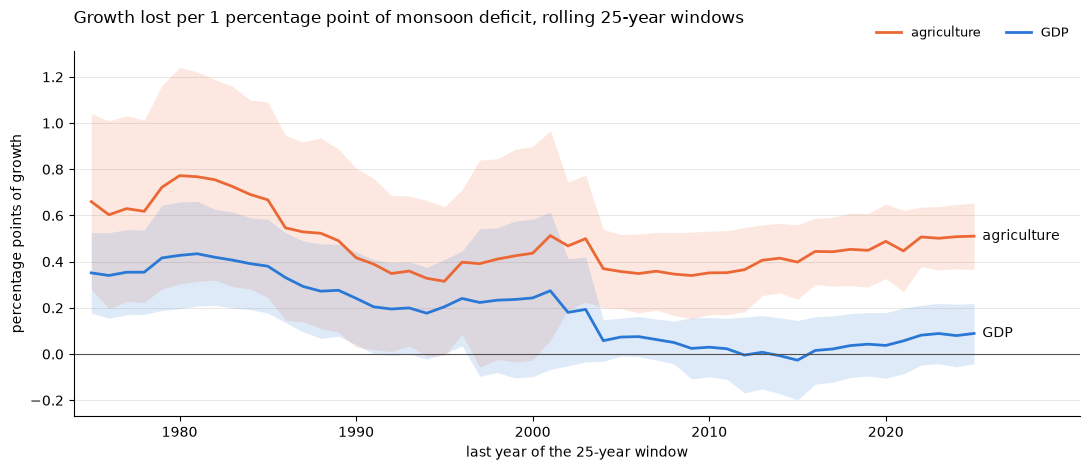

In [12]:
fig, ax = plt.subplots(figsize=(11, 4.8))
for col, color, label in [("agri", "#eb6834", "agriculture"), ("gdp", "#2a78d6", "GDP")]:
    ax.plot(rolling.index, rolling[col], color=color, linewidth=2, label=label)
    ax.fill_between(rolling.index, rolling[col] - 1.96 * rolling[col + "_se"],
                    rolling[col] + 1.96 * rolling[col + "_se"], color=color, alpha=0.15, linewidth=0)
    ax.annotate(label, (rolling.index[-1], rolling[col].iloc[-1]), xytext=(6, 0),
                textcoords="offset points", va="center", fontsize=10, color="#0b0b0b")

ax.axhline(0, color="#52514e", linewidth=0.8)
ax.set_title("Growth lost per 1 percentage point of monsoon deficit, rolling 25-year windows", loc="left", pad=20)
ax.legend(loc="lower right", bbox_to_anchor=(1, 1.0), ncol=2, frameon=False, fontsize=9)
ax.set_xlabel("last year of the 25-year window")
ax.set_ylabel("percentage points of growth")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#e5e4e0", linewidth=0.6)
ax.set_axisbelow(True)
ax.set_xlim(rolling.index[0] - 1, rolling.index[-1] + 6)
ax.set_xticks(range(1980, 2030, 10))
plt.tight_layout()
plt.show()

## What this could mean for 2026

The 2026 monsoon was 12.6% below normal. Applying the post-1991 farm estimate gives a rough idea of the hit to 2026-27 farm growth. It is an illustration, not a forecast.

In [13]:
m = fit("agri_growth ~ deficit + surplus", df[df["after_1991"] == 1])
departure_2026 = rain.loc[2026, "departure"]
coef, se = m.params["deficit"], m.bse["deficit"]
low_coef, high_coef = coef - 1.96 * se, coef + 1.96 * se

print(f"2026 monsoon departure from normal: {departure_2026:.1f}%")
print(f"post-1991 effect per point of deficit: {coef:.2f} (95% range {low_coef:.2f} to {high_coef:.2f})")
print(f"implied drop in 2026-27 farm growth compared with a normal year: about {abs(coef * departure_2026):.1f} points "
      f"(range {abs(low_coef * departure_2026):.1f} to {abs(high_coef * departure_2026):.1f})")

2026 monsoon departure from normal: -12.6%
post-1991 effect per point of deficit: 0.42 (95% range 0.29 to 0.56)
implied drop in 2026-27 farm growth compared with a normal year: about 5.3 points (range 3.6 to 7.1)


## Saving the data

In [14]:
cols = ["monsoon_year", "agri_growth", "nonagri_growth", "gva_growth", "gdp_growth", "agri_share",
        "pct_of_normal", "departure", "category"]
df[cols].round(3).to_csv(CLEAN + "growth_and_monsoon_1951_2025.csv")